# Analyse exploratoire SPY - version enrichie

Ce notebook charge les données SPY, analyse les rendements et compare plusieurs mesures de risque, y compris les VaR rolling historique, gaussienne et ARMA-GARCH.

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from volatility_risk import load_spy_returns
def rolling_historical_var(returns, lookback=252, alpha=0.01):
    """Version optimisée de la VaR historique (vectorisée)"""
    return -returns.rolling(window=lookback).quantile(alpha)

def rolling_gaussian_var(returns, lookback=252, alpha=0.01):
    """Version optimisée de la VaR gaussienne (vectorisée)"""
    rolling_mean = returns.rolling(window=lookback).mean()
    rolling_std = returns.rolling(window=lookback).std()
    return -(rolling_mean + rolling_std * norm.ppf(alpha))

def rolling_arma_garch_var(returns, lookback=252, alpha=0.01, step=10):
    """Version optimisée de la VaR ARMA-GARCH (calcul tous les step jours)"""
    from arch import arch_model
    from tqdm import tqdm
    
    var_series = pd.Series(index=returns.index[lookback:], dtype=float)
    indices = range(lookback, len(returns), step)
    
    for i in tqdm(indices, desc="ARMA-GARCH", leave=False):
        window = returns.iloc[i-lookback:i]
        try:
            model = arch_model(window, mean='Constant', vol='GARCH', p=1, q=1)
            res = model.fit(disp='off', options={'maxiter': 100})
            forecast = res.forecast(horizon=1)
            mean_f = forecast.mean.iloc[-1, 0]
            var_f = forecast.variance.iloc[-1, 0]
            var_series.iloc[i-lookback] = -(mean_f + np.sqrt(var_f) * norm.ppf(alpha))
        except:
            var_series.iloc[i-lookback] = np.nan
    
    return var_series.interpolate(method='linear', limit_direction='both')

plt.style.use('seaborn-v0_8')
csv_path = os.path.join('data', 'SPY_2010-01-01_2026-08-03.csv')
returns = load_spy_returns(csv_path)
# Charger les prix avec un fallback robuste selon le format du CSV
try:
    df_prices = pd.read_csv(csv_path, parse_dates=['Date'], index_col='Date')
    if 'Adj Close' in df_prices.columns:
        prices = df_prices[['Adj Close']].rename(columns={'Adj Close': 'price'})
    elif 'Close' in df_prices.columns:
        prices = df_prices[['Close']].rename(columns={'Close': 'price'})
    else:
        raise ValueError('Pas de colonne Adj Close/Close dans le CSV lu avec parse_dates')
except Exception:
    df_prices = pd.read_csv(csv_path, header=[0, 1, 2], low_memory=False)
    date_col = None
    for col in df_prices.columns:
        if isinstance(col, tuple) and any(str(p) == 'Date' for p in col):
            date_col = col
            break
        elif str(col) == 'Date':
            date_col = col
            break
    if date_col is not None:
        df_prices[date_col] = pd.to_datetime(df_prices[date_col])
        df_prices = df_prices.set_index(date_col)
        price_col = None
        for col in df_prices.columns:
            if isinstance(col, tuple) and col[0] in ['Adj Close', 'Close', 'Price']:
                price_col = col
                break
            elif col in ['Adj Close', 'Close', 'Price']:
                price_col = col
                break
        if price_col is None:
            raise ValueError('Aucune colonne de prix trouvée dans le CSV multi-header')
        prices = df_prices[[price_col]].astype(float).rename(columns={price_col: 'price'})
    else:
        df_prices = pd.read_csv(csv_path)
        first_col = df_prices.columns[0]
        df_prices[first_col] = pd.to_datetime(df_prices[first_col], errors='coerce')
        df_prices = df_prices.set_index(first_col)
        if 'Adj Close' in df_prices.columns:
            prices = df_prices[['Adj Close']].rename(columns={'Adj Close': 'price'})
        elif 'Close' in df_prices.columns:
            prices = df_prices[['Close']].rename(columns={'Close': 'price'})
        else:
            numeric_cols = df_prices.select_dtypes(include=[float, int]).columns
            if len(numeric_cols) > 0:
                prices = df_prices[[numeric_cols[-1]]].rename(columns={numeric_cols[-1]: 'price'})
            else:
                raise ValueError('Impossible de trouver une colonne de prix dans le CSV')


In [7]:
display(returns.head())
summary = pd.Series({
    'count': len(returns),
    'mean': returns.mean(),
    'std': returns.std(ddof=1),
    'skew': returns.skew(),
    'kurtosis': returns.kurtosis(),
    'min': returns.min(),
    'max': returns.max(),
})
display(summary.to_frame(name='value'))


(Price, Ticker, Date)
2010-01-05    0.002644
2010-01-06    0.000704
2010-01-07    0.004212
2010-01-08    0.003322
2010-01-11    0.001396
Name: log_return, dtype: float64

,value
count,4168.000000
mean,0.000523
std,0.010796
skew,-0.556558
kurtosis,12.378758
min,-0.115887
max,0.099863


In [3]:
print(prices.columns.tolist())

[('Adj Close', 'SPY', 'Unnamed: 1_level_2')]


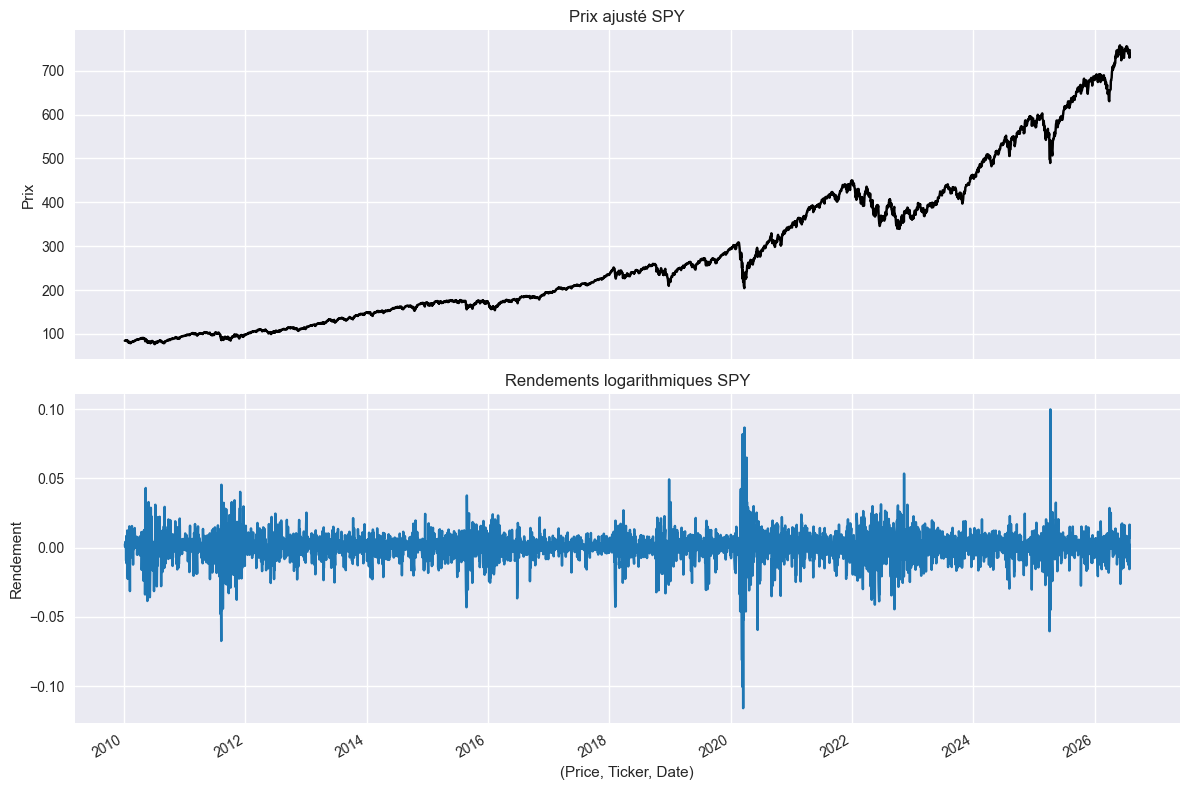

In [8]:
# Une ligne pour tout résoudre
prices.columns = ['price']

# Puis votre code original
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
prices['price'].plot(ax=axes[0], color='black', title='Prix ajusté SPY')
axes[0].set_ylabel('Prix')
returns.plot(ax=axes[1], color='tab:blue', title='Rendements logarithmiques SPY')
axes[1].set_ylabel('Rendement')
plt.tight_layout()
plt.show()


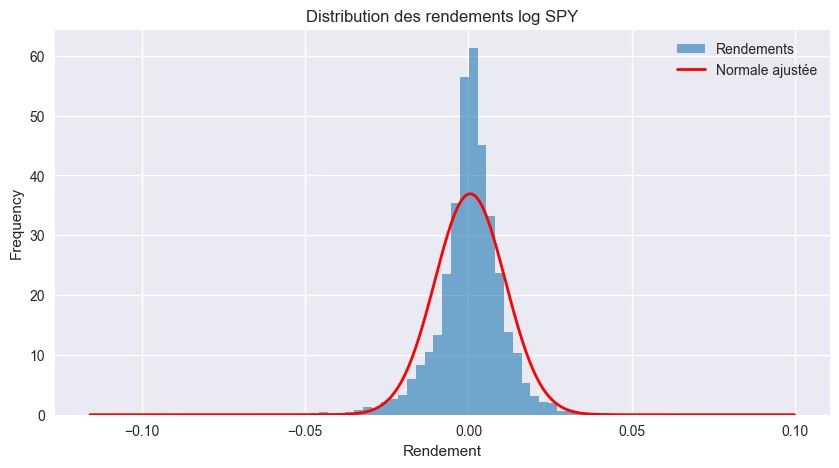

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
returns.plot(kind='hist', bins=80, density=True, ax=ax, color='tab:blue', alpha=0.6, label='Rendements')
x = np.linspace(returns.min(), returns.max(), 200)
ax.plot(x, norm.pdf(x, returns.mean(), returns.std(ddof=1)), color='red', lw=2, label='Normale ajustée')
ax.set_title('Distribution des rendements log SPY')
ax.set_xlabel('Rendement')
ax.legend()
plt.show()


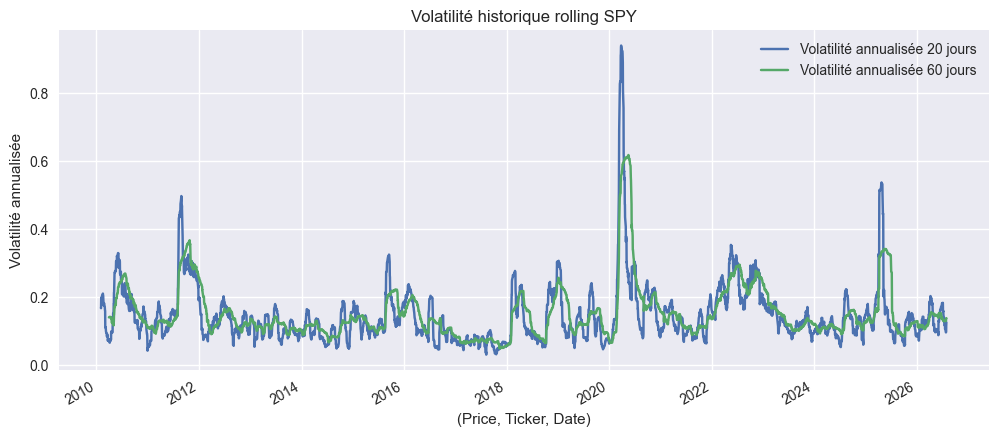

In [10]:
rolling_short = returns.rolling(window=20).std(ddof=1) * np.sqrt(252)
rolling_medium = returns.rolling(window=60).std(ddof=1) * np.sqrt(252)

fig, ax = plt.subplots(figsize=(12, 5))
rolling_short.plot(ax=ax, label='Volatilité annualisée 20 jours')
rolling_medium.plot(ax=ax, label='Volatilité annualisée 60 jours')
ax.set_title('Volatilité historique rolling SPY')
ax.set_ylabel('Volatilité annualisée')
ax.legend()
plt.show()


## Backtesting VaR rolling

Le notebook compare trois méthodes de VaR rolling : historique, gaussienne et ARMA-GARCH.

Calcul des VaR rolling...
1. VaR historique...
    Terminé
2. VaR gaussienne...
    Terminé
3. VaR ARMA-GARCH (calcul tous les 10 jours)...


ARMA-GARCH:   0%|          | 0/392 [00:00<?, ?it/s]c:\Users\Elève\AppData\Local\Programs\Python\Python314\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001265. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
ARMA-GARCH:   0%|          | 1/392 [00:03<23:10,  3.56s/it]c:\Users\Elève\AppData\Local\Programs\Python\Python314\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001253. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be dis

    Terminé


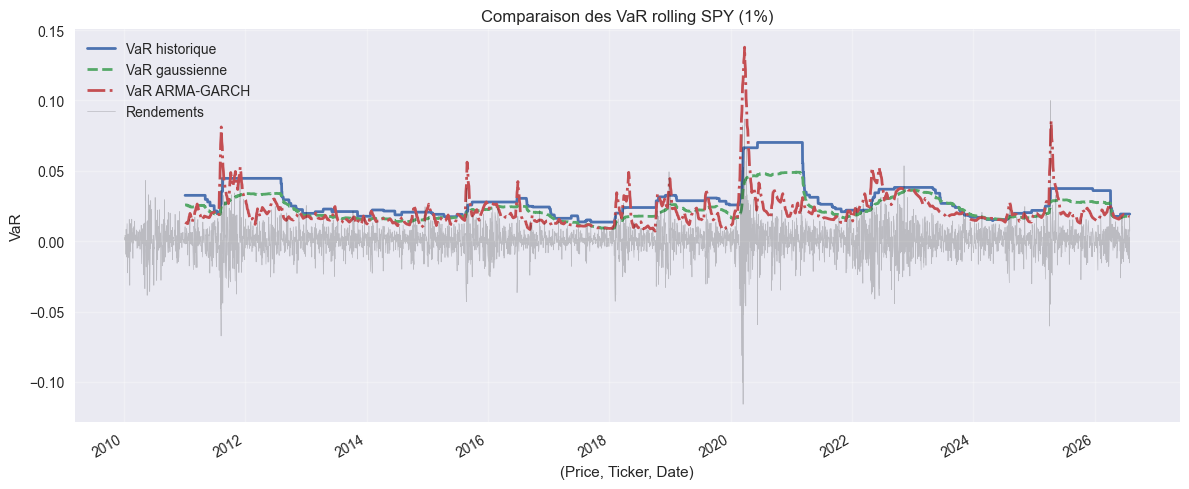

In [11]:
lookback = 252
alpha = 0.01

print("Calcul des VaR rolling...")
print("="*50)

print("1. VaR historique...")
hist_var = rolling_historical_var(returns, lookback=lookback, alpha=alpha)
print("    Terminé")

print("2. VaR gaussienne...")
gauss_var = rolling_gaussian_var(returns, lookback=lookback, alpha=alpha)
print("    Terminé")

print("3. VaR ARMA-GARCH (calcul tous les 10 jours)...")
arma_garch_var = rolling_arma_garch_var(returns, lookback=lookback, alpha=alpha, step=10)
print("    Terminé")

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
hist_var.plot(ax=ax, label='VaR historique', linewidth=2)
gauss_var.plot(ax=ax, label='VaR gaussienne', linewidth=2, linestyle='--')
arma_garch_var.plot(ax=ax, label='VaR ARMA-GARCH', linewidth=2, linestyle='-.')
returns.plot(ax=ax, color='black', alpha=0.2, linewidth=0.5, label='Rendements')
ax.set_title('Comparaison des VaR rolling SPY (1%)', fontsize=12)
ax.set_ylabel('VaR', fontsize=11)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Résultats de backtesting

On compte les exceptions de VaR et on compare les taux d'échec entre les modèles.

In [12]:
def count_exceptions(returns, var_series):
    return (returns < -var_series).astype(int)

def make_summary(name, var_series):
    exc = count_exceptions(returns.loc[var_series.index], var_series).dropna()
    return pd.Series({
        'method': name,
        'n_obs': len(exc),
        'exceptions': int(exc.sum()),
        'exception_rate': float(exc.mean()),
        'expected_rate': alpha,
    })

summary = pd.DataFrame([
    make_summary('historical', hist_var),
    make_summary('gaussian', gauss_var),
    make_summary('arma-garch', arma_garch_var),
])
summary


,method,n_obs,exceptions,exception_rate,expected_rate
0,historical,4168,53,0.012716,0.01
1,gaussian,4168,104,0.024952,0.01
2,arma-garch,3916,72,0.018386,0.01


In [ ]:
# Statistiques de violations de VaR
# Compter les dépassements de VaR
common_index = hist_var.dropna().index
violations_hist = (returns.loc[common_index] < -hist_var.loc[common_index]).sum()
violations_gauss = (returns.loc[common_index] < -gauss_var.loc[common_index]).sum()

# Pour ARMA-GARCH (avec interpolation, pas de NaN)
garch_valid = arma_garch_var.dropna().index
violations_garch = (returns.loc[garch_valid] < -arma_garch_var.loc[garch_valid]).sum()

print(f"Nombre total de points: {len(common_index)}")
print(f"Violations VaR historique: {violations_hist} ({violations_hist/len(common_index)*100:.2f}%)")
print(f"Violations VaR gaussienne: {violations_gauss} ({violations_gauss/len(common_index)*100:.2f}%)")
print(f"Violations VaR ARMA-GARCH: {violations_garch} ({violations_garch/len(garch_valid)*100:.2f}%)")

Nombre total de points: 3917
Violations VaR historique: 53 (1.35%)
Violations VaR gaussienne: 104 (2.66%)
Violations VaR ARMA-GARCH: 72 (1.84%)


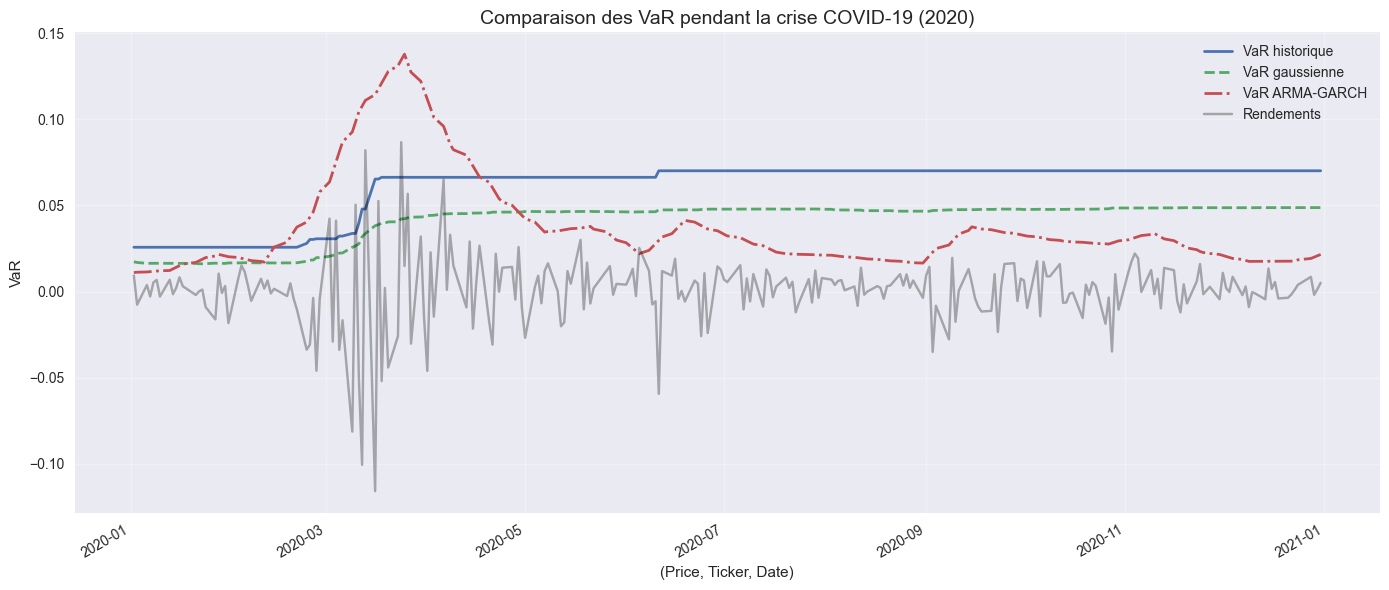

In [14]:
# Zoom sur la période de crise COVID-19 (2020)
# Par exemple, le COVID-19 (2020)
fig, ax = plt.subplots(figsize=(14, 6))
start_date = '2020-01-01'
end_date = '2020-12-31'

hist_var.loc[start_date:end_date].plot(ax=ax, label='VaR historique', linewidth=2)
gauss_var.loc[start_date:end_date].plot(ax=ax, label='VaR gaussienne', linewidth=2, linestyle='--')
arma_garch_var.loc[start_date:end_date].plot(ax=ax, label='VaR ARMA-GARCH', linewidth=2, linestyle='-.')
returns.loc[start_date:end_date].plot(ax=ax, color='black', alpha=0.3, label='Rendements')

ax.set_title('Comparaison des VaR pendant la crise COVID-19 (2020)', fontsize=14)
ax.set_ylabel('VaR')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Sauvegarde des résultats dans un fichier CSV
# Sauvegarder les VaR calculées
results = pd.DataFrame({
    'VaR_historique': hist_var,
    'VaR_gaussienne': gauss_var,
    'VaR_ARMA_GARCH': arma_garch_var
})
results.to_csv(os.path.join('data', 'VaR_results.csv'))
print("Résultats sauvegardés dans data/VaR_results.csv")

Résultats sauvegardés dans data/VaR_results.csv
